# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 15: EXPANDED HYBRID FUSION MODEL
# ============================================================
# Purpose:
# This notebook combines the expanded structured model branch
# and the expanded audio CNN branch into an expanded hybrid
# genre classification model.
#
# The goal is to:
# 1. Load probability outputs from the expanded structured model
# 2. Load probability outputs from the expanded audio CNN
# 3. Fuse the two probability vectors
# 4. Evaluate hybrid performance on validation and test sets
# 5. Compare expanded structured-only, expanded CNN-only,
#    and expanded hybrid results
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# ============================================================
# 2. LOAD EXPANDED STRUCTURED OUTPUTS
# ============================================================

val_probs_rf = np.load("../data/processed/val_probs_rf_expanded.npy")
structured_test_probs = np.load("../data/processed/structured_test_probs_best_expanded.npy")

y_val_structured = np.load("../data/processed/y_val_structured_expanded.npy")
y_test_structured = np.load("../data/processed/y_test_structured_expanded.npy")

structured_classes = np.load(
    "../data/processed/structured_label_classes_expanded.npy",
    allow_pickle=True
)

with open("../data/processed/best_structured_model_name_expanded.txt", "r") as f:
    best_structured_model_name = f.read()

with open("../data/processed/best_structured_model_test_accuracy_expanded.txt", "r") as f:
    structured_test_accuracy = float(f.read())

print("Best expanded structured model:", best_structured_model_name)
print("Expanded structured test accuracy:", structured_test_accuracy)
print("Expanded structured classes:", structured_classes)

Best expanded structured model: Random Forest
Expanded structured test accuracy: 0.41333333333333333
Expanded structured classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [3]:
# ============================================================
# 3. LOAD EXPANDED CNN OUTPUTS
# ============================================================

val_probs_cnn = np.load("../data/processed/val_probs_cnn_expanded.npy")
test_probs_cnn = np.load("../data/processed/test_probs_cnn_expanded.npy")

y_val_cnn = np.load("../data/processed/y_val_cnn_expanded.npy")
y_test_cnn = np.load("../data/processed/y_test_cnn_expanded.npy")

cnn_classes = np.load(
    "../data/processed/cnn_label_classes_expanded.npy",
    allow_pickle=True
)

with open("../data/processed/improved_cnn_test_accuracy_expanded.txt", "r") as f:
    improved_cnn_test_accuracy = float(f.read())

print("Expanded CNN test accuracy:", improved_cnn_test_accuracy)
print("Expanded CNN classes:", cnn_classes)

Expanded CNN test accuracy: 0.41333332657814026
Expanded CNN classes: ['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [4]:
# ============================================================
# 4. CHECK ALIGNMENT
# ============================================================

print("Validation labels match:", np.array_equal(y_val_structured, y_val_cnn))
print("Test labels match:", np.array_equal(y_test_structured, y_test_cnn))
print("Class labels match:", np.array_equal(structured_classes, cnn_classes))

Validation labels match: True
Test labels match: True
Class labels match: True


In [5]:
# ============================================================
# 5. DEFINE FUSION FUNCTION
# ============================================================

def fuse_probabilities(probs_structured, probs_cnn, w_structured=0.5, w_cnn=0.5):
    return (w_structured * probs_structured) + (w_cnn * probs_cnn)

In [6]:
# ============================================================
# 6. TRY DIFFERENT FUSION WEIGHTS ON VALIDATION SET
# ============================================================

fusion_results = []

weight_options = [
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
]

for w_structured, w_cnn in weight_options:
    fused_val_probs = fuse_probabilities(
        val_probs_rf,
        val_probs_cnn,
        w_structured=w_structured,
        w_cnn=w_cnn
    )

    fused_val_pred = np.argmax(fused_val_probs, axis=1)
    fused_val_acc = accuracy_score(y_val_structured, fused_val_pred)

    fusion_results.append({
        "Structured Weight": w_structured,
        "CNN Weight": w_cnn,
        "Validation Accuracy": fused_val_acc
    })

fusion_results_df = pd.DataFrame(fusion_results)

print("Expanded Fusion Validation Results:")
display(fusion_results_df.sort_values("Validation Accuracy", ascending=False))

Expanded Fusion Validation Results:


,Structured Weight,CNN Weight,Validation Accuracy
7,0.8,0.2,0.552486
6,0.7,0.3,0.552486
8,0.9,0.1,0.541436
5,0.6,0.4,0.535912
4,0.5,0.5,0.530387
3,0.4,0.6,0.513812
2,0.3,0.7,0.500000
1,0.2,0.8,0.491713
0,0.1,0.9,0.477901


In [7]:
# ============================================================
# 7. SELECT BEST FUSION WEIGHTS
# ============================================================

best_row = fusion_results_df.sort_values("Validation Accuracy", ascending=False).iloc[0]

best_w_structured = best_row["Structured Weight"]
best_w_cnn = best_row["CNN Weight"]
best_fusion_val_acc = best_row["Validation Accuracy"]

print("Best expanded fusion weights:")
print("Structured weight:", best_w_structured)
print("CNN weight:", best_w_cnn)
print("Best expanded fusion validation accuracy:", best_fusion_val_acc)

Best expanded fusion weights:
Structured weight: 0.8
CNN weight: 0.2
Best expanded fusion validation accuracy: 0.5524861878453039


In [8]:
# ============================================================
# 8. EVALUATE EXPANDED HYBRID MODEL ON TEST SET
# ============================================================

hybrid_test_probs = fuse_probabilities(
    structured_test_probs,
    test_probs_cnn,
    w_structured=best_w_structured,
    w_cnn=best_w_cnn
)

hybrid_test_pred = np.argmax(hybrid_test_probs, axis=1)
hybrid_test_accuracy = accuracy_score(y_test_structured, hybrid_test_pred)

print("Expanded Hybrid Test Accuracy:", hybrid_test_accuracy)

Expanded Hybrid Test Accuracy: 0.44266666666666665


In [9]:
# ============================================================
# 9. EXPANDED HYBRID CLASSIFICATION REPORT
# ============================================================

print(classification_report(
    y_test_structured,
    hybrid_test_pred,
    target_names=structured_classes,
    zero_division=0
))

              precision    recall  f1-score   support

   Classical       0.76      0.64      0.70        25
  Electronic       0.38      0.38      0.38        50
Experimental       0.32      0.32      0.32        50
        Folk       0.39      0.44      0.41        50
     Hip-Hop       0.71      0.88      0.79        50
Instrumental       0.24      0.20      0.22        50
         Pop       0.25      0.14      0.18        50
        Rock       0.48      0.64      0.55        50

    accuracy                           0.44       375
   macro avg       0.44      0.46      0.44       375
weighted avg       0.42      0.44      0.43       375



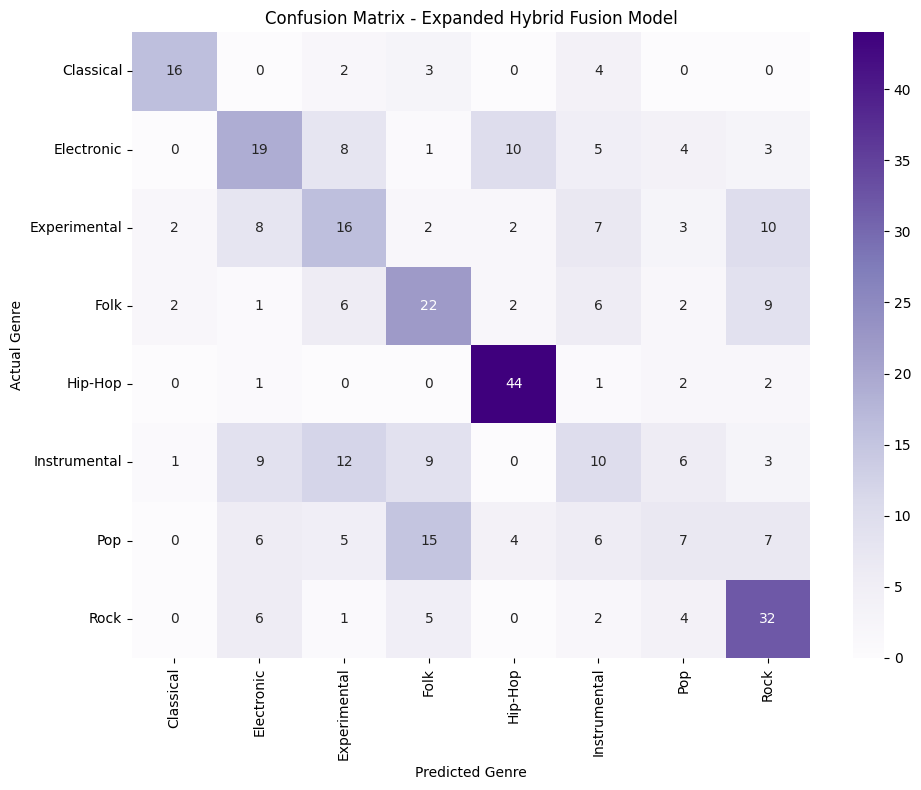

In [10]:
# ============================================================
# 10. EXPANDED HYBRID CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test_structured, hybrid_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=structured_classes,
    yticklabels=structured_classes
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("Confusion Matrix - Expanded Hybrid Fusion Model")
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# 11. FINAL EXPANDED MODEL COMPARISON
# ============================================================

final_comparison = pd.DataFrame({
    "Model": [
        "Expanded Best Structured Model",
        "Expanded Audio CNN",
        "Expanded Hybrid Fusion Model"
    ],
    "Test Accuracy": [
        structured_test_accuracy,
        improved_cnn_test_accuracy,
        hybrid_test_accuracy
    ]
})

print("Expanded Final Model Comparison:")
display(final_comparison)

Expanded Final Model Comparison:


,Model,Test Accuracy
0,Expanded Best Structured Model,0.413333
1,Expanded Audio CNN,0.413333
2,Expanded Hybrid Fusion Model,0.442667


In [12]:
# ============================================================
# 12. SAVE EXPANDED HYBRID RESULTS
# ============================================================

os.makedirs("../data/processed", exist_ok=True)

with open("../data/processed/hybrid_test_accuracy_expanded.txt", "w") as f:
    f.write(str(hybrid_test_accuracy))

final_comparison.to_csv(
    "../data/processed/final_model_comparison_expanded.csv",
    index=False
)

print("Saved expanded hybrid results.")

Saved expanded hybrid results.


In [13]:
# ============================================================
# 13. INTERPRETATION NOTES
# ============================================================

print("1. This notebook combines the expanded structured and expanded CNN branches.")
print("2. Validation data is used to determine the best expanded fusion weighting.")
print("3. The final result shows whether expansion improved the hybrid system.")
print("4. This lets us compare the original validated hybrid pipeline against the expanded retrained version.")

1. This notebook combines the expanded structured and expanded CNN branches.
2. Validation data is used to determine the best expanded fusion weighting.
3. The final result shows whether expansion improved the hybrid system.
4. This lets us compare the original validated hybrid pipeline against the expanded retrained version.
